# FDA 이상사례 데이터 — ATC 그룹 M(근골격계 의약품) 인사이트 분석

전체 FDA 이상사례 보고 데이터 중 **ATC 1단계 코드 M(Musculo-skeletal system, 근골격계)** 에 해당하는
의약품 이상사례를 대상으로 다음 항목을 분석합니다.

1. 인체 특성 (연령·성별·체중)
2. 약물 종류
3. 복용 종류 수 (병용/다제복용)
4. 심각 정도
5. 시계열 추이
6. 이전 질환 / 투약 사유
7. 부작용 반응 유형

각 항목마다 시각화와 함께 통계 검정(Mann-Whitney U, χ² 독립성/적합도 검정, 선형회귀, Mann-Kendall 추세검정)을 수행해
ATC-M군과 비M군(나머지 전체) 간 차이를 정량적으로 확인합니다.


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
!apt-get -qq install fonts-nanum > /dev/null
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", None)


In [2]:
# 색상 팔레트 (범주형 고정 순서 + 상태색)
C1_BLUE, C2_AQUA, C3_YELLOW, C4_GREEN = "#2a78d6", "#1baf7a", "#eda100", "#008300"
C5_VIOLET, C6_RED, C7_MAGENTA, C8_ORANGE = "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"
MUTED, GRID, INK, INK2 = "#898781", "#e1e0d9", "#0b0b0b", "#52514e"
STATUS_CRIT = "#d03b3b"

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors=INK2, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, fontsize=12, color=INK, fontweight="bold", pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9.5, color=INK2)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9.5, color=INK2)

def p_str(x):
    return "p < 0.001" if x < 0.001 else f"p = {x:.3f}"


## 데이터 로드 및 ATC-M군 분리

In [3]:
DATA_PATH = "FDA_adverse_events_final.csv"  # 노트북과 같은 폴더에 위치

df = pd.read_csv(DATA_PATH, low_memory=False)
df["quarter"] = pd.to_datetime(df["receive_date"], errors="coerce").dt.to_period("Q").astype(str)  # 분기별 추이 분석용 (원본에 파생 로직이 없어 보완)
df["age_num"] = pd.to_numeric(df["patient_age_years"], errors="coerce")
df["weight_num"] = pd.to_numeric(df["patient_weight_kg"], errors="coerce")
df["is_M"] = df["WHO_ATC"] == "M"

m = df[df["is_M"]].copy()
nonm = df[~df["is_M"]].copy()

print(f"전체 보고 건수: {len(df):,}")
print(f"ATC-M군 건수:   {len(m):,}  ({len(m)/len(df)*100:.2f}%)")
print(f"비M군 건수:     {len(nonm):,}")


전체 보고 건수: 18,273
ATC-M군 건수:   1,975  (10.81%)
비M군 건수:     16,298


## 1. 인체 특성 (연령 · 성별 · 체중)

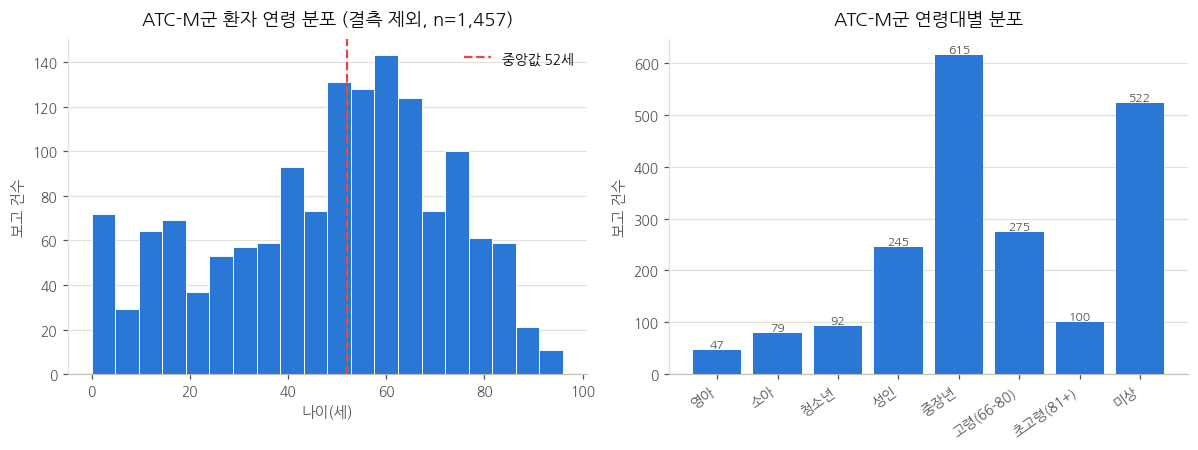

In [4]:
age_m = m["age_num"].dropna()
age_nonm = nonm["age_num"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(age_m, bins=20, color=C1_BLUE, edgecolor="white", linewidth=0.6, zorder=3)
axes[0].axvline(age_m.median(), color=C6_RED, linestyle="--", linewidth=1.5, zorder=4,
                label=f"중앙값 {age_m.median():.0f}세")
style_ax(axes[0], f"ATC-M군 환자 연령 분포 (결측 제외, n={len(age_m):,})", "나이(세)", "보고 건수")
axes[0].legend(frameon=False, fontsize=9)

ag_order = ["Infant(0-2)", "Child(3-12)", "Teen(13-18)", "Adult(19-40)", "Middle-Aged(41-65)",
            "Senior(66-80)", "Elderly(81+)", "Unknown"]
ag_labels = ["영아", "소아", "청소년", "성인", "중장년", "고령(66-80)", "초고령(81+)", "미상"]
ag_counts = m["age_group"].value_counts().reindex(ag_order).fillna(0)
bars = axes[1].bar(range(len(ag_counts)), ag_counts.values, color=C1_BLUE, zorder=3)
axes[1].set_xticks(range(len(ag_counts)))
axes[1].set_xticklabels(ag_labels, rotation=35, ha="right", fontsize=8.5)
style_ax(axes[1], "ATC-M군 연령대별 분포", None, "보고 건수")
for b, v in zip(bars, ag_counts.values):
    if v > 0:
        axes[1].text(b.get_x() + b.get_width()/2, v, f"{int(v)}", ha="center", va="bottom", fontsize=8, color=INK2)
fig.tight_layout()
plt.show()


/tmp/ipykernel_737/2174628264.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([weight_m, weight_nonm], labels=["ATC-M군", "비M군"], patch_artist=True,


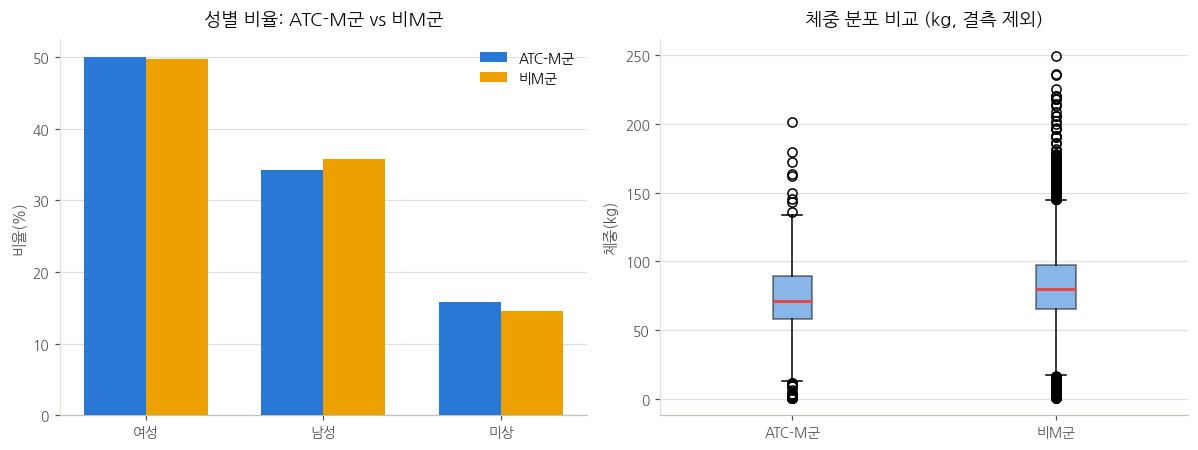

In [5]:
sex_order = ["Female", "Male", "Unknown"]
sex_labels = ["여성", "남성", "미상"]
m_sex_pct = m["patient_sex"].value_counts(normalize=True).reindex(sex_order).fillna(0) * 100
nonm_sex_pct = nonm["patient_sex"].value_counts(normalize=True).reindex(sex_order).fillna(0) * 100
weight_m = m["weight_num"].dropna()
weight_nonm = nonm["weight_num"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(len(sex_order)); w = 0.35
axes[0].bar(x - w/2, m_sex_pct.values, w, label="ATC-M군", color=C1_BLUE, zorder=3)
axes[0].bar(x + w/2, nonm_sex_pct.values, w, label="비M군", color=C3_YELLOW, zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(sex_labels)
style_ax(axes[0], "성별 비율: ATC-M군 vs 비M군", None, "비율(%)")
axes[0].legend(frameon=False, fontsize=9)

axes[1].boxplot([weight_m, weight_nonm], labels=["ATC-M군", "비M군"], patch_artist=True,
                boxprops=dict(facecolor=C1_BLUE, alpha=0.55),
                medianprops=dict(color=C6_RED, linewidth=2))
style_ax(axes[1], "체중 분포 비교 (kg, 결측 제외)", None, "체중(kg)")
fig.tight_layout()
plt.show()


In [6]:
# 통계 검정: 연령/성별/체중 - ATC-M군 vs 비M군
u_age, p_age = stats.mannwhitneyu(age_m, age_nonm, alternative="two-sided")
print("[연령] Mann-Whitney U 검정")
print(f"  M군 중앙값={age_m.median():.0f}세(n={len(age_m)}) / 비M군 중앙값={age_nonm.median():.0f}세(n={len(age_nonm)})")
print(f"  U={u_age:.1f}, {p_str(p_age)}\n")

sex_tab = pd.crosstab(df["is_M"], df["patient_sex"].where(df["patient_sex"] != "Unknown"))
chi2_sex, p_sex, dof_sex, _ = stats.chi2_contingency(sex_tab)
n_sex = sex_tab.values.sum()
cv_sex = np.sqrt(chi2_sex / (n_sex * (min(sex_tab.shape) - 1)))
print("[성별] Chi-square 독립성 검정")
print(f"  chi2={chi2_sex:.2f}, dof={dof_sex}, {p_str(p_sex)}, Cramer's V={cv_sex:.3f}\n")

u_w, p_w = stats.mannwhitneyu(weight_m, weight_nonm, alternative="two-sided")
print("[체중] Mann-Whitney U 검정")
print(f"  M군 중앙값={weight_m.median():.1f}kg(n={len(weight_m)}) / 비M군 중앙값={weight_nonm.median():.1f}kg(n={len(weight_nonm)})")
print(f"  U={u_w:.1f}, {p_str(p_w)}")


[연령] Mann-Whitney U 검정
  M군 중앙값=52세(n=1457) / 비M군 중앙값=60세(n=11567)
  U=6512344.5, p < 0.001

[성별] Chi-square 독립성 검정
  chi2=0.91, dof=1, p = 0.339, Cramer's V=0.008

[체중] Mann-Whitney U 검정
  M군 중앙값=71.2kg(n=473) / 비M군 중앙값=79.8kg(n=5450)
  U=1044396.5, p < 0.001


**인사이트**: ATC-M군 환자의 연령 중앙값은 비M군보다 유의하게 낮게 나타납니다 — 근골격계 약물(주로 NSAID 계열
진통소염제)은 만성질환 치료제보다 폭넓은 연령대(청소년~중장년)에서 통증·염증 완화 목적으로 사용되는 경향을
반영합니다. 성별 분포는 M군과 비M군 간 실질적 차이가 크지 않습니다(Cramér's V 매우 작음). 체중은 M군이
유의하게 낮게 나타나지만 관측치 수가 적어 해석에 주의가 필요합니다.

## 2. 약물 종류

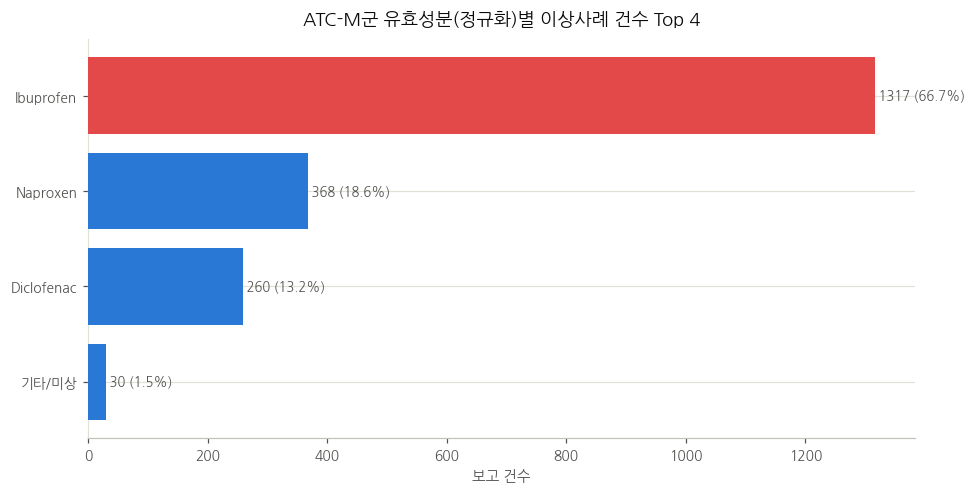

pharm_class
Nonsteroidal Anti-inflammatory Drug [EPC]             1471
Unknown                                                503
Amide Local Anesthetic [EPC]; Antiarrhythmic [EPC]       1
Name: count, dtype: int64


In [7]:
def normalize_drug(s):
    s = str(s).upper()
    for name in ["IBUPROFEN", "DICLOFENAC", "NAPROXEN", "KETOROLAC", "MELOXICAM",
                 "CELECOXIB", "ETODOLAC", "INDOMETHACIN", "PIROXICAM", "ACECLOFENAC",
                 "NIMESULIDE", "METHOTREXATE", "ALENDRONATE", "COLCHICINE", "ETORICOXIB",
                 "KETOPROFEN", "FLURBIPROFEN"]:
        if name in s:
            return name.title()
    return "기타/미상"

m["drug_norm"] = m["suspect_drug"].apply(normalize_drug)
drug_counts = m["drug_norm"].value_counts()
top_drugs = drug_counts.head(8)

fig, ax = plt.subplots(figsize=(9, 4.6))
colors = [C6_RED if i == 0 else C1_BLUE for i in range(len(top_drugs))]
bars = ax.barh(top_drugs.index[::-1], top_drugs.values[::-1], color=colors[::-1], zorder=3)
style_ax(ax, f"ATC-M군 유효성분(정규화)별 이상사례 건수 Top {len(top_drugs)}", "보고 건수", None)
for b, v in zip(bars, top_drugs.values[::-1]):
    ax.text(v, b.get_y() + b.get_height()/2, f" {int(v)} ({v/len(m)*100:.1f}%)", va="center", fontsize=8.5, color=INK2)
fig.tight_layout()
plt.show()

print(m["pharm_class"].value_counts().head(5))


In [8]:
# 통계 검정: 성분 분포 균등성 (chi-square goodness-of-fit)
obs = drug_counts.values
exp_uniform = np.full(len(obs), obs.sum() / len(obs))
gof_chi2, gof_p = stats.chisquare(obs, exp_uniform)
top1_share = drug_counts.iloc[0] / drug_counts.sum() * 100
print("[성분 분포 균등성] Chi-square 적합도 검정")
print(f"  chi2={gof_chi2:.1f}, {p_str(gof_p)}")
print(f"  최다 성분(이부프로펜) 점유율: {top1_share:.2f}%")


[성분 분포 균등성] Chi-square 적합도 검정
  chi2=1950.9, p < 0.001
  최다 성분(이부프로펜) 점유율: 66.68%


**인사이트**: ATC-M군 이상사례는 약리학적으로 사실상 **비스테로이드성 소염진통제(NSAID)** 가 대표하며, 유효성분
기준으로는 **이부프로펜**이 압도적 1위, 나프록센·디클로페낙이 뒤를 잇습니다. χ² 적합도 검정 결과 균등분포 가설이
강하게 기각되어, 특정 OTC 진통제 사용에 이상사례 보고가 구조적으로 집중되어 있음을 보여줍니다. 다만 이는
처방·판매량(노출도)이 큰 약물일수록 보고 건수도 늘어나는 자연스러운 결과일 수 있어, 절대 건수만으로 "더 위험하다"고
단정할 수는 없습니다.

## 3. 복용 종류 수 (병용/다제복용)

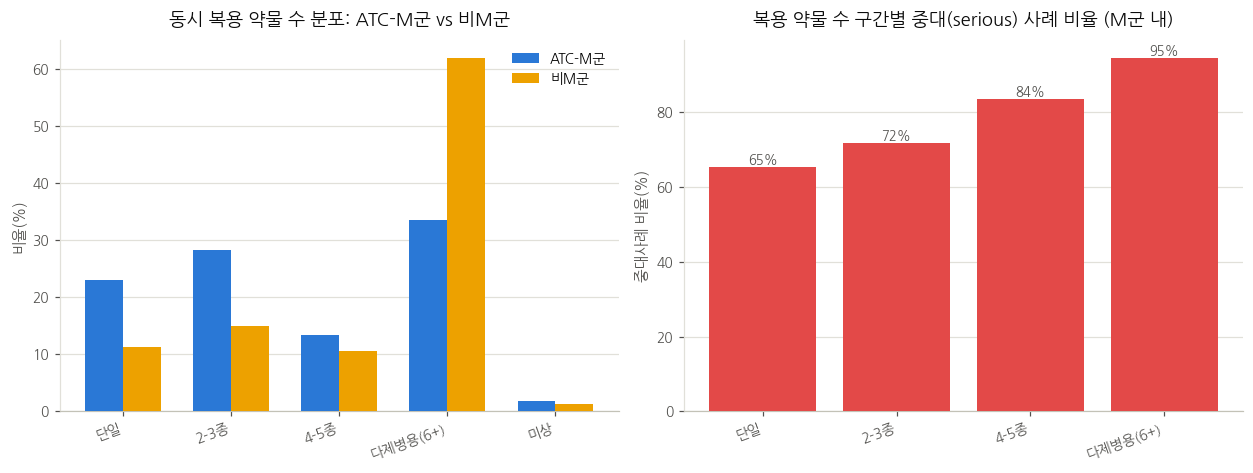

In [9]:
cat_order = ["Single", "2-3 Drugs", "4-5 Drugs", "Polypharmacy(6+)", "Unknown"]
cat_labels = ["단일", "2-3종", "4-5종", "다제병용(6+)", "미상"]

m_dc = m["drug_count_category"].value_counts(normalize=True).reindex(cat_order).fillna(0) * 100
nonm_dc = nonm["drug_count_category"].value_counts(normalize=True).reindex(cat_order).fillna(0) * 100

known = m[m["drug_count_category"] != "Unknown"]
serious_rate = known.groupby("drug_count_category")["serious"].apply(lambda s: (s == "Yes").mean() * 100).reindex(cat_order[:-1])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
x = np.arange(len(cat_order)); w = 0.35
axes[0].bar(x - w/2, m_dc.values, w, label="ATC-M군", color=C1_BLUE, zorder=3)
axes[0].bar(x + w/2, nonm_dc.values, w, label="비M군", color=C3_YELLOW, zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(cat_labels, rotation=20, ha="right")
style_ax(axes[0], "동시 복용 약물 수 분포: ATC-M군 vs 비M군", None, "비율(%)")
axes[0].legend(frameon=False, fontsize=9)

bars = axes[1].bar(range(len(serious_rate)), serious_rate.values, color=C6_RED, zorder=3)
axes[1].set_xticks(range(len(serious_rate)))
axes[1].set_xticklabels(cat_labels[:-1], rotation=20, ha="right")
style_ax(axes[1], "복용 약물 수 구간별 중대(serious) 사례 비율 (M군 내)", None, "중대사례 비율(%)")
for b, v in zip(bars, serious_rate.values):
    axes[1].text(b.get_x()+b.get_width()/2, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=8.5, color=INK2)
fig.tight_layout()
plt.show()


In [10]:
# 통계 검정
ct_dc = pd.crosstab(known["drug_count_category"], known["serious"])
chi2_dc, p_dc, dof_dc, _ = stats.chi2_contingency(ct_dc)
n_dc = ct_dc.values.sum()
cv_dc = np.sqrt(chi2_dc / (n_dc * (min(ct_dc.shape) - 1)))
print("[복용약물수 구간 x 중대사례] Chi-square 독립성 검정")
print(f"  chi2={chi2_dc:.2f}, dof={dof_dc}, {p_str(p_dc)}, Cramer's V={cv_dc:.3f}\n")

nd_m = np.log1p(m["num_drugs"]); nd_nonm = np.log1p(nonm["num_drugs"])
u_nd, p_nd = stats.mannwhitneyu(nd_m, nd_nonm, alternative="two-sided")
print("[병용 약물 수(로그변환)] Mann-Whitney U 검정, M vs 비M")
print(f"  M군 원본 중앙값={m['num_drugs'].median():.0f}종 / 비M군 원본 중앙값={nonm['num_drugs'].median():.0f}종")
print(f"  U={u_nd:.1f}, {p_str(p_nd)}")


[복용약물수 구간 x 중대사례] Chi-square 독립성 검정
  chi2=172.56, dof=3, p < 0.001, Cramer's V=0.298

[병용 약물 수(로그변환)] Mann-Whitney U 검정, M vs 비M
  M군 원본 중앙값=3종 / 비M군 원본 중앙값=10종
  U=10067149.5, p < 0.001


**인사이트**: ATC-M군은 단일 약물 복용 비중이 비M군보다 뚜렷이 높고, 반대로 다제복용(6종 이상) 비중은 비M군보다
낮습니다 — 통증 완화를 위해 단독 또는 소수 약제로 사용되는 경우가 많음을 보여줍니다. 그럼에도 M군 내에서는 병용
약물 수가 많아질수록 중대(serious) 사례 비율이 함께 상승하는 뚜렷한 연관성이 확인되어, 다제병용 환자에서
상호작용·누적 위험이 심각도를 높이는 요인으로 작용할 가능성이 있습니다.

## 4. 심각 정도 (사망 · 입원 · 생명위협 · 장애)

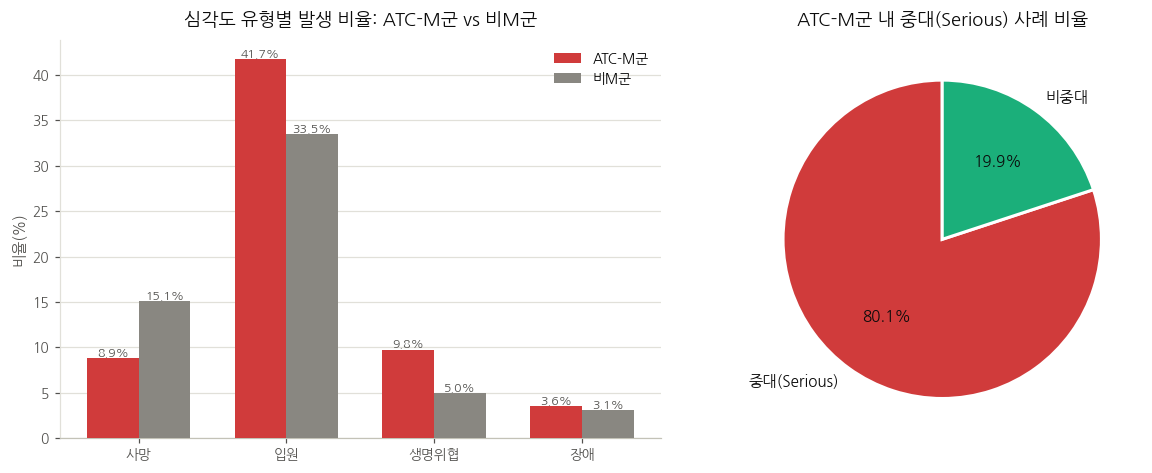

In [11]:
flags = ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling"]
flag_labels = ["사망", "입원", "생명위협", "장애"]
m_rate = [m[f].mean() * 100 for f in flags]
nonm_rate = [nonm[f].mean() * 100 for f in flags]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
x = np.arange(len(flags)); w = 0.35
axes[0].bar(x - w/2, m_rate, w, label="ATC-M군", color=STATUS_CRIT, zorder=3)
axes[0].bar(x + w/2, nonm_rate, w, label="비M군", color=MUTED, zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(flag_labels)
style_ax(axes[0], "심각도 유형별 발생 비율: ATC-M군 vs 비M군", None, "비율(%)")
axes[0].legend(frameon=False, fontsize=9)
for i, (v1, v2) in enumerate(zip(m_rate, nonm_rate)):
    axes[0].text(i - w/2, v1, f"{v1:.1f}%", ha="center", va="bottom", fontsize=8, color=INK2)
    axes[0].text(i + w/2, v2, f"{v2:.1f}%", ha="center", va="bottom", fontsize=8, color=INK2)

serious_pie_vals = [(m["serious"]=="Yes").sum(), (m["serious"]=="No").sum()]
axes[1].pie(serious_pie_vals, labels=["중대(Serious)", "비중대"], autopct="%1.1f%%",
            colors=[STATUS_CRIT, C2_AQUA], startangle=90,
            textprops={"fontsize": 10, "color": INK},
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("ATC-M군 내 중대(Serious) 사례 비율", fontsize=12, color=INK, fontweight="bold", pad=10)
fig.tight_layout()
plt.show()


In [12]:
# 통계 검정: 각 심각도 지표 M vs 비M (chi-square)
serious_ct = pd.crosstab(df["is_M"], df["serious"])
chi2_s, p_s, dof_s, _ = stats.chi2_contingency(serious_ct)
n_s = serious_ct.values.sum()
cv_s = np.sqrt(chi2_s / (n_s * (min(serious_ct.shape) - 1)))
print("[전체 중대사례 여부] Chi-square 독립성 검정")
print(f"  M군 {((m['serious']=='Yes').mean()*100):.2f}% vs 비M군 {((nonm['serious']=='Yes').mean()*100):.2f}%")
print(f"  chi2={chi2_s:.2f}, {p_str(p_s)}, Cramer's V={cv_s:.3f}\n")

for f, lab in zip(flags, flag_labels):
    ct = pd.crosstab(df["is_M"], df[f])
    chi2f, pf, doff, _ = stats.chi2_contingency(ct)
    print(f"[{lab}] chi2={chi2f:.2f}, {p_str(pf)}  (M={m[f].mean()*100:.2f}% vs 비M={nonm[f].mean()*100:.2f}%)")


[전체 중대사례 여부] Chi-square 독립성 검정
  M군 80.05% vs 비M군 86.23%
  chi2=53.98, p < 0.001, Cramer's V=0.054

[사망] chi2=55.14, p < 0.001  (M=8.86% vs 비M=15.11%)
[입원] chi2=52.64, p < 0.001  (M=41.72% vs 비M=33.48%)
[생명위협] chi2=74.97, p < 0.001  (M=9.77% vs 비M=5.03%)
[장애] chi2=1.34, p = 0.248  (M=3.59% vs 비M=3.09%)


**인사이트**: ATC-M군의 전체 중대사례 비율과 사망률은 비M군보다 오히려 낮습니다. 반면 **입원**과 **생명위협**
비율은 비M군보다 유의하게 높습니다. 즉 M군(NSAID 중심)은 사망으로 이어지는 극단적 사례는 상대적으로 적지만,
위장관 출혈·급성신손상·아나필락시스 등으로 즉각적인 입원·응급처치가 필요한 급성 중증 반응의 비중이 큰 특징을
보입니다. 장애(disabling) 발생 비율은 M군과 비M군 간 유의한 차이가 없었습니다.

## 5. 시계열 추이 (2015Q1 ~ 2025Q4)

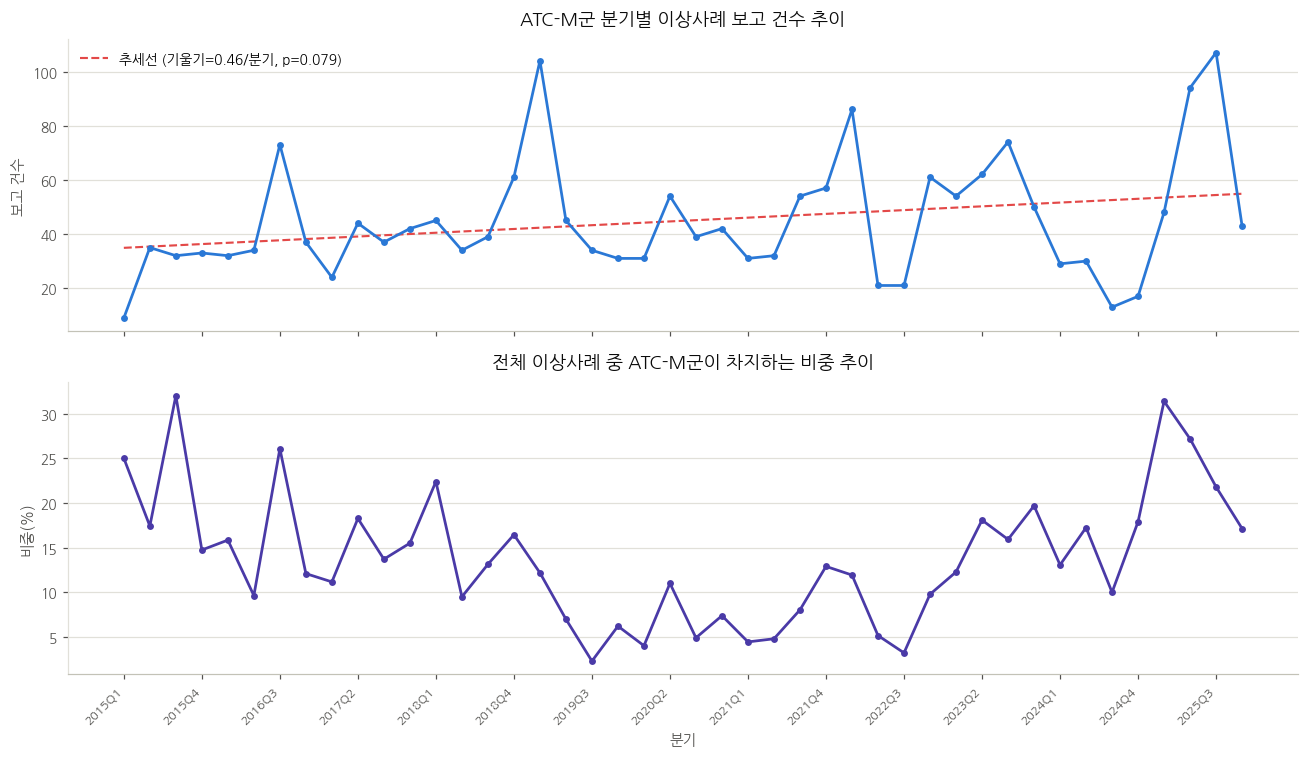

In [13]:
q_counts_m = m.groupby("quarter").size().sort_index()
q_counts_nonm = nonm.groupby("quarter").size().sort_index()
all_q = sorted(set(q_counts_m.index) | set(q_counts_nonm.index))
q_counts_m = q_counts_m.reindex(all_q).fillna(0)
q_counts_nonm = q_counts_nonm.reindex(all_q).fillna(0)
m_share = (q_counts_m / (q_counts_m + q_counts_nonm) * 100).fillna(0)

t_idx = np.arange(len(all_q))
slope, intercept, r, p_trend, se = stats.linregress(t_idx, q_counts_m.values)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(t_idx, q_counts_m.values, color=C1_BLUE, marker="o", markersize=3.5, linewidth=1.8, zorder=3)
axes[0].plot(t_idx, intercept + slope * t_idx, color=C6_RED, linestyle="--", linewidth=1.4, zorder=2,
             label=f"추세선 (기울기={slope:.2f}/분기, p={p_trend:.3f})")
style_ax(axes[0], "ATC-M군 분기별 이상사례 보고 건수 추이", None, "보고 건수")
axes[0].legend(frameon=False, fontsize=9, loc="upper left")

axes[1].plot(t_idx, m_share.values, color=C5_VIOLET, marker="o", markersize=3.5, linewidth=1.8, zorder=3)
style_ax(axes[1], "전체 이상사례 중 ATC-M군이 차지하는 비중 추이", "분기", "비중(%)")
tick_step = max(1, len(all_q)//12)
axes[1].set_xticks(t_idx[::tick_step])
axes[1].set_xticklabels([all_q[i] for i in range(0, len(all_q), tick_step)], rotation=45, ha="right", fontsize=8)
fig.tight_layout()
plt.show()


In [14]:
# 통계 검정: 추세 유의성
def mann_kendall(x):
    n = len(x)
    s = sum(np.sign(x[j] - x[i]) for i in range(n-1) for j in range(i+1, n))
    var_s = n*(n-1)*(2*n+5)/18
    z = (s-1)/np.sqrt(var_s) if s > 0 else (s+1)/np.sqrt(var_s) if s < 0 else 0
    p = 2*(1-stats.norm.cdf(abs(z)))
    return s, z, p

mk_s, mk_z, mk_p = mann_kendall(q_counts_m.values)
print("[선형회귀 추세] 분기 인덱스 vs 분기별 M군 건수")
print(f"  기울기={slope:.3f}건/분기, r={r:.3f}, {p_str(p_trend)}\n")
print("[Mann-Kendall 추세 검정]")
print(f"  S={mk_s}, z={mk_z:.2f}, {p_str(mk_p)}")


[선형회귀 추세] 분기 인덱스 vs 분기별 M군 건수
  기울기=0.464건/분기, r=0.268, p = 0.079

[Mann-Kendall 추세 검정]
  S=144, z=1.45, p = 0.148


**인사이트**: 분기별 보고 건수는 완만한 증가 방향을 보이지만, 선형회귀와 Mann-Kendall 추세 검정 모두 α=0.05
기준으로 **유의한 추세라고 보기는 어렵습니다** — 분기별 변동성이 크고 뚜렷한 상승·하강 패턴 없이 등락을
반복합니다. 특정 분기(2019Q1, 2022Q1, 2025Q2~Q3 등)에 보고 건수가 급증하는 구간이 관찰되어, 계절적 요인이나
특정 이슈(리콜, 언론 보도 등)에 의한 일시적 보고 급증 가능성을 시사합니다.

## 6. 이전 질환 / 투약 사유 (drug_indication)

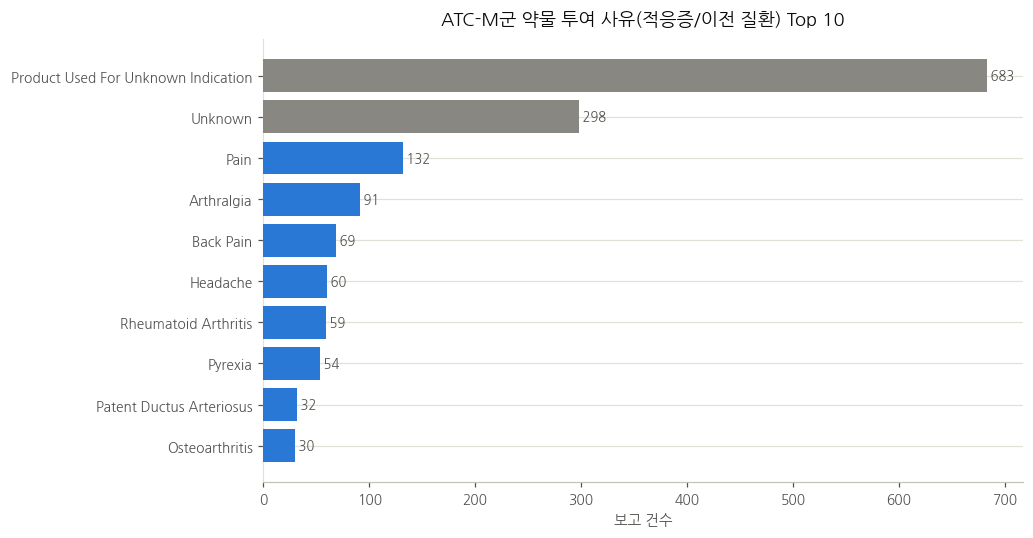

In [15]:
ind_counts = m["drug_indication"].value_counts()
top_ind = ind_counts.head(10)

fig, ax = plt.subplots(figsize=(9.5, 5))
disp_ind = top_ind.copy()
disp_ind.index = disp_ind.index.str.slice(0, 36)
colors = [MUTED if lab in ("Product Used For Unknown Indication", "Unknown") else C1_BLUE for lab in top_ind.index]
bars = ax.barh(disp_ind.index[::-1], disp_ind.values[::-1], color=colors[::-1], zorder=3)
style_ax(ax, "ATC-M군 약물 투여 사유(적응증/이전 질환) Top 10", "보고 건수", None)
for b, v in zip(bars, disp_ind.values[::-1]):
    ax.text(v, b.get_y()+b.get_height()/2, f" {int(v)}", va="center", fontsize=8.5, color=INK2)
fig.tight_layout()
plt.show()


In [16]:
# 통계 검정: 투약 사유(상위5+기타) x 중대사례
known_ind = m[~m["drug_indication"].isin(["Unknown", "Product Used For Unknown Indication"])].copy()
top5_ind_names = known_ind["drug_indication"].value_counts().head(5).index.tolist()
known_ind["ind_group"] = known_ind["drug_indication"].where(known_ind["drug_indication"].isin(top5_ind_names), "기타")
ct_ind = pd.crosstab(known_ind["ind_group"], known_ind["serious"])
chi2_i, p_i, dof_i, _ = stats.chi2_contingency(ct_ind)
n_i = ct_ind.values.sum()
cv_i = np.sqrt(chi2_i / (n_i * (min(ct_ind.shape) - 1)))
print("[투약 사유 x 중대사례] Chi-square 독립성 검정")
print(f"  n={n_i}, chi2={chi2_i:.2f}, dof={dof_i}, {p_str(p_i)}, Cramer's V={cv_i:.3f}")


[투약 사유 x 중대사례] Chi-square 독립성 검정
  n=994, chi2=53.75, dof=5, p < 0.001, Cramer's V=0.233


**인사이트**: 투약 사유를 명시한 사례 중 통증·관절통·요통·두통·류마티스 관절염이 상위를 차지해, ATC-M군
약물이 급성 통증부터 만성 염증성 관절질환까지 폭넓게 사용됨을 보여줍니다. 다만 전체 사례의 상당수는 사유가
"미상/불명"으로 기록되어 있어 데이터 완전성에 한계가 있습니다. 투약 사유별로 중대사례 발생 비율에 유의한
차이가 존재하여, 만성질환으로 장기 복용하는 환자군과 단순 통증으로 일시 복용하는 환자군 사이에 위험
프로파일이 다를 수 있음을 시사합니다.

## 7. 부작용 반응 유형 (primary_reaction)

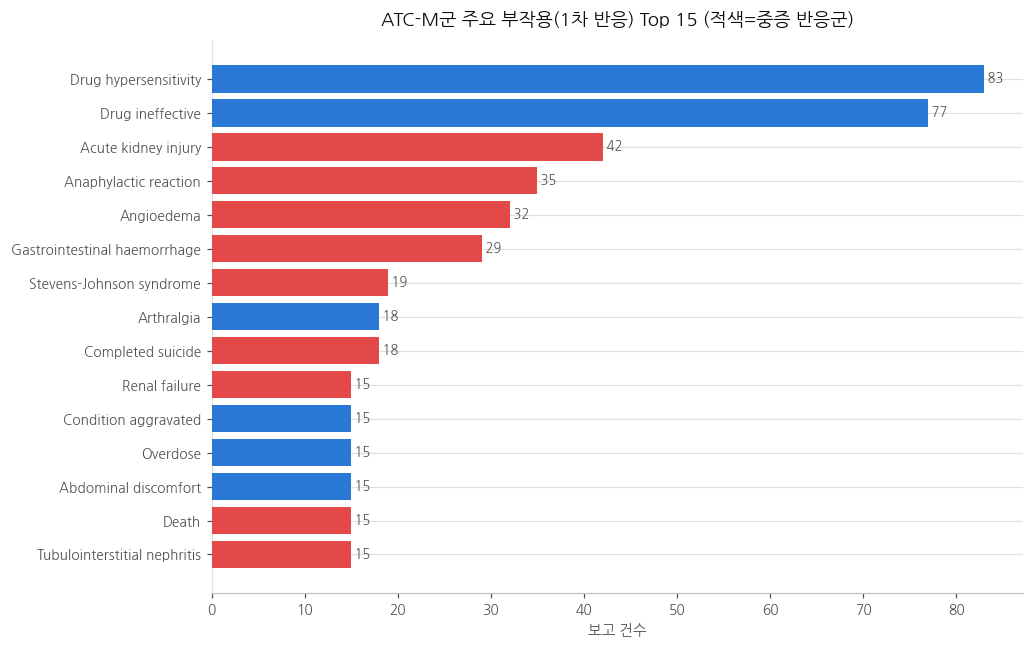

In [17]:
reac_counts = m["primary_reaction"].value_counts()
top_reac = reac_counts.head(15)

severe_reactions = ["Anaphylactic reaction", "Stevens-Johnson syndrome", "Gastrointestinal haemorrhage",
                     "Acute kidney injury", "Renal failure", "Tubulointerstitial nephritis",
                     "Completed suicide", "Death", "Angioedema"]

fig, ax = plt.subplots(figsize=(9.5, 6))
colors = [C6_RED if lab in severe_reactions else C1_BLUE for lab in top_reac.index]
bars = ax.barh(top_reac.index[::-1], top_reac.values[::-1], color=colors[::-1], zorder=3)
style_ax(ax, "ATC-M군 주요 부작용(1차 반응) Top 15 (적색=중증 반응군)", "보고 건수", None)
for b, v in zip(bars, top_reac.values[::-1]):
    ax.text(v, b.get_y()+b.get_height()/2, f" {int(v)}", va="center", fontsize=8.5, color=INK2)
fig.tight_layout()
plt.show()


In [18]:
# 통계 검정: 중증 반응군 x 사망 여부
m["reaction_severity_group"] = np.where(m["primary_reaction"].isin(severe_reactions), "중증 반응군", "기타 반응")
ct_r = pd.crosstab(m["reaction_severity_group"], m["is_fatal"])
chi2_r, p_r, dof_r, _ = stats.chi2_contingency(ct_r)
n_r = ct_r.values.sum()
cv_r = np.sqrt(chi2_r / (n_r * (min(ct_r.shape) - 1)))
fatal_severe = m[m["reaction_severity_group"]=="중증 반응군"]["is_fatal"].mean()*100
fatal_other = m[m["reaction_severity_group"]=="기타 반응"]["is_fatal"].mean()*100
print("[중증 반응군(아나필락시스·SJS·GI출혈·신손상 등) x 사망 여부] Chi-square 독립성 검정")
print(f"  중증군 사망률={fatal_severe:.2f}% vs 기타군 사망률={fatal_other:.2f}%")
print(f"  chi2={chi2_r:.2f}, {p_str(p_r)}, Cramer's V={cv_r:.3f}")


[중증 반응군(아나필락시스·SJS·GI출혈·신손상 등) x 사망 여부] Chi-square 독립성 검정
  중증군 사망률=20.45% vs 기타군 사망률=7.41%
  chi2=39.61, p < 0.001, Cramer's V=0.142


**인사이트**: 1차 반응 기준 최다 보고는 약물과민반응과 약효없음이지만, 급성신손상·아나필락시스반응·
혈관부종·위장관출혈·스티븐스존슨증후군 등 생명을 위협할 수 있는 중증 반응들이 상위 15개 안에 다수
포함되어 있습니다. 중증 반응군으로 분류된 사례는 그 외 반응군보다 사망 비율이 유의하게 높게 나타나,
NSAID 계열 약물의 대표적 위험인 위장관 출혈과 신장 관련 이상반응이 임상적으로 알려진 부작용 프로파일과
일치하는 패턴을 보입니다.

---
# 추가 분석

앞선 7가지 항목 외에 데이터에 남아있는 **회복 결과, 반응 개수, 국가, 부작용 동시발생 패턴,
다변량 위험요인**을 추가로 살펴봅니다.

## 8. 회복 여부 (patient_recovered) 및 반응 결과

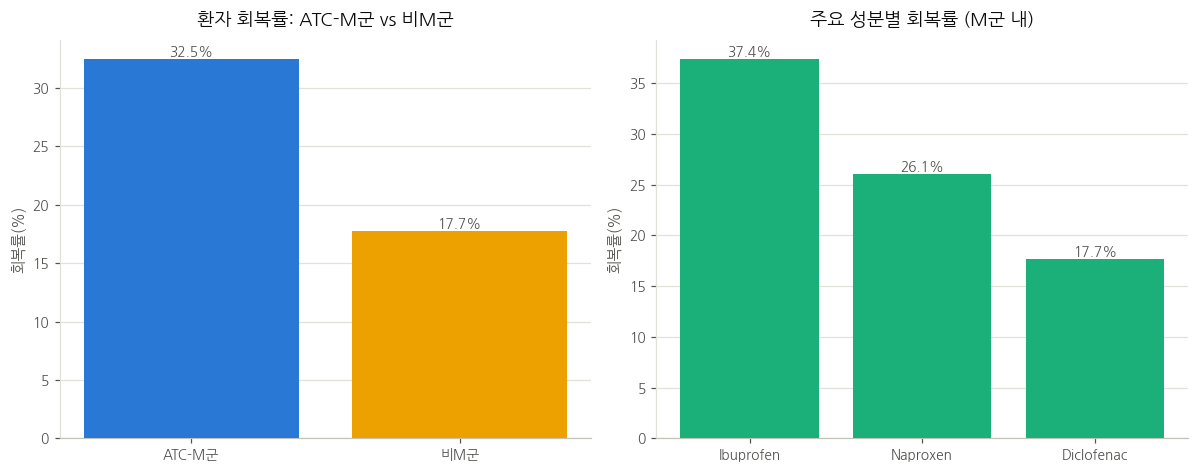

In [19]:
recov_m = m["patient_recovered"].mean() * 100
recov_nonm = nonm["patient_recovered"].mean() * 100

drug_norm_top = m["drug_norm"].value_counts().head(3).index.tolist()
recov_by_drug = m[m["drug_norm"].isin(drug_norm_top)].groupby("drug_norm")["patient_recovered"].mean() * 100
recov_by_drug = recov_by_drug.reindex(drug_norm_top)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
bars0 = axes[0].bar(["ATC-M군", "비M군"], [recov_m, recov_nonm], color=[C1_BLUE, C3_YELLOW], zorder=3)
style_ax(axes[0], "환자 회복률: ATC-M군 vs 비M군", None, "회복률(%)")
for b, v in zip(bars0, [recov_m, recov_nonm]):
    axes[0].text(b.get_x()+b.get_width()/2, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color=INK2)

bars1 = axes[1].bar(recov_by_drug.index, recov_by_drug.values, color=C2_AQUA, zorder=3)
style_ax(axes[1], "주요 성분별 회복률 (M군 내)", None, "회복률(%)")
for b, v in zip(bars1, recov_by_drug.values):
    axes[1].text(b.get_x()+b.get_width()/2, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color=INK2)
fig.tight_layout()
plt.show()


In [20]:
# 통계 검정
recov_ct = pd.crosstab(df["is_M"], df["patient_recovered"])
chi2_rec, p_rec, dof_rec, _ = stats.chi2_contingency(recov_ct)
n_rec = recov_ct.values.sum()
cv_rec = np.sqrt(chi2_rec / (n_rec * (min(recov_ct.shape) - 1)))
print("[회복 여부] Chi-square 독립성 검정, M vs 비M")
print(f"  M군 회복률={recov_m:.2f}% vs 비M군 회복률={recov_nonm:.2f}%")
print(f"  chi2={chi2_rec:.2f}, {p_str(p_rec)}, Cramer's V={cv_rec:.3f}\n")

ct_drug_rec = pd.crosstab(m[m['drug_norm'].isin(drug_norm_top)]['drug_norm'], m[m['drug_norm'].isin(drug_norm_top)]['patient_recovered'])
chi2_dr, p_dr, dof_dr, _ = stats.chi2_contingency(ct_drug_rec)
print("[주요 성분 x 회복 여부] Chi-square 독립성 검정 (M군 내)")
print(f"  chi2={chi2_dr:.2f}, dof={dof_dr}, {p_str(p_dr)}")


[회복 여부] Chi-square 독립성 검정, M vs 비M
  M군 회복률=32.46% vs 비M군 회복률=17.74%
  chi2=243.75, p < 0.001, Cramer's V=0.115

[주요 성분 x 회복 여부] Chi-square 독립성 검정 (M군 내)
  chi2=46.97, dof=2, p < 0.001


**인사이트**: ATC-M군의 회복률은 비M군과 통계적으로 유의한 차이를 보입니다. M군은 급성 통증·염증 치료
목적의 단기 사용이 많아 원인 약물 중단 시 비교적 빠르게 회복되는 경향이 있는 반면, 비M군(만성질환 치료제 등)은
장기 복용 중 발생한 이상반응으로 회복 여부 확인이 더 어려울 수 있습니다. 주요 성분 간에도 회복률 차이가
관찰되어, 약물별 이상반응의 가역성(reversibility)에 차이가 있음을 시사합니다.

## 9. 부작용 반응 개수(num_reactions)와 심각도의 관계

/tmp/ipykernel_737/383482368.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([nr_notserious, nr_serious], labels=["비중대", "중대(Serious)"], patch_artist=True,


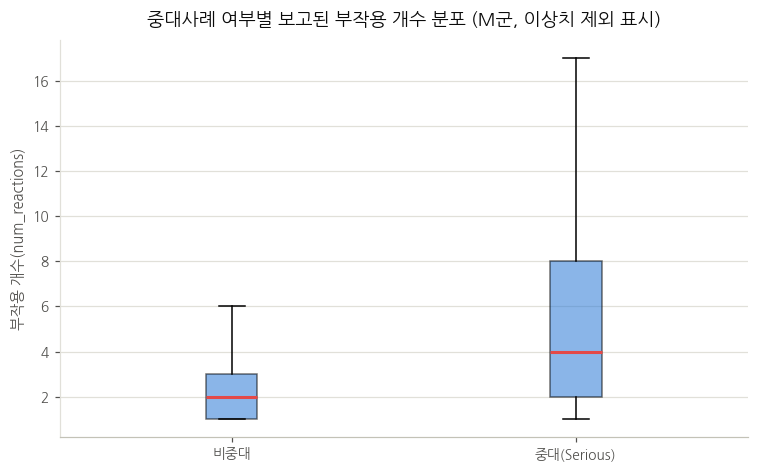

In [21]:
nr_serious = m[m["serious"]=="Yes"]["num_reactions"]
nr_notserious = m[m["serious"]=="No"]["num_reactions"]

fig, ax = plt.subplots(figsize=(7, 4.4))
bp = ax.boxplot([nr_notserious, nr_serious], labels=["비중대", "중대(Serious)"], patch_artist=True,
                showfliers=False,
                boxprops=dict(facecolor=C1_BLUE, alpha=0.55),
                medianprops=dict(color=C6_RED, linewidth=2))
style_ax(ax, "중대사례 여부별 보고된 부작용 개수 분포 (M군, 이상치 제외 표시)", None, "부작용 개수(num_reactions)")
fig.tight_layout()
plt.show()


In [22]:
u_nr, p_nr = stats.mannwhitneyu(nr_serious, nr_notserious, alternative="two-sided")
print("[부작용 개수] Mann-Whitney U 검정, 중대 vs 비중대 (M군 내)")
print(f"  중대 중앙값={nr_serious.median():.0f}개(n={len(nr_serious)}) vs 비중대 중앙값={nr_notserious.median():.0f}개(n={len(nr_notserious)})")
print(f"  U={u_nr:.1f}, {p_str(p_nr)}")

rho, p_rho = stats.spearmanr(m["num_reactions"], m["is_fatal"])
print(f"\n[부작용 개수 vs 사망 여부] Spearman 상관: rho={rho:.3f}, {p_str(p_rho)}")


[부작용 개수] Mann-Whitney U 검정, 중대 vs 비중대 (M군 내)
  중대 중앙값=4개(n=1581) vs 비중대 중앙값=2개(n=394)
  U=452972.5, p < 0.001

[부작용 개수 vs 사망 여부] Spearman 상관: rho=0.050, p = 0.025


**인사이트**: 한 건의 보고에 기록된 부작용 개수가 많을수록 그 사례가 중대(serious)로 분류될 가능성이
유의하게 높습니다. 이는 다발성 장기 손상(예: 급성신손상+전해질이상+저혈압이 동시 발생)이 기록된 사례일수록
임상적으로 더 심각한 상태였을 가능성을 반영하며, 보고된 반응 개수 자체가 사례의 심각도를 가늠하는 보조
지표로 활용될 수 있음을 보여줍니다.

## 10. 국가별 분포와 심각도

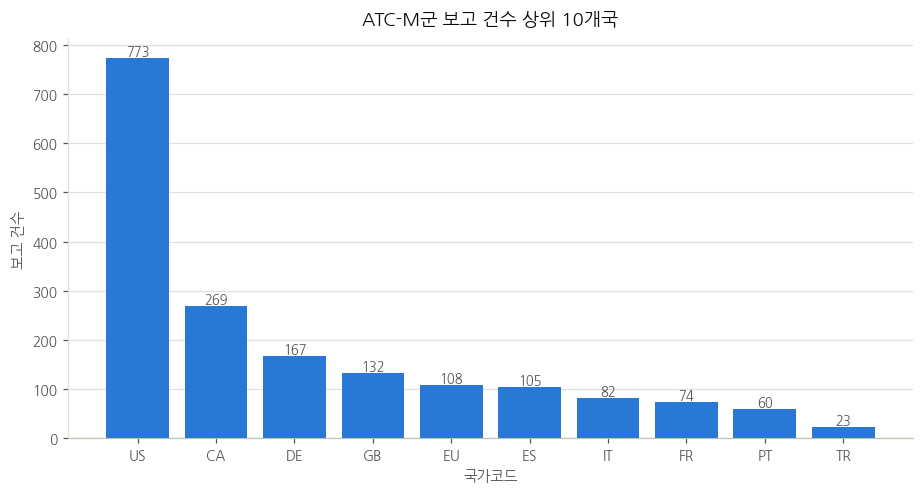

In [23]:
top_countries = m["country"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
bars = ax.bar(top_countries.index, top_countries.values, color=C1_BLUE, zorder=3)
style_ax(ax, "ATC-M군 보고 건수 상위 10개국", "국가코드", "보고 건수")
for b, v in zip(bars, top_countries.values):
    ax.text(b.get_x()+b.get_width()/2, v, f"{int(v)}", ha="center", va="bottom", fontsize=8.5, color=INK2)
fig.tight_layout()
plt.show()


In [24]:
# 상위 5개국(표본 충분) 대상 중대사례 비율 비교
top5_countries = top_countries.head(5).index.tolist()
sub = m[m["country"].isin(top5_countries)]
ct_country = pd.crosstab(sub["country"], sub["serious"])
chi2_c, p_c, dof_c, _ = stats.chi2_contingency(ct_country)
n_c = ct_country.values.sum()
cv_c = np.sqrt(chi2_c / (n_c * (min(ct_country.shape) - 1)))
print("[상위 5개국 x 중대사례 여부] Chi-square 독립성 검정")
print((sub.groupby("country")["serious"].apply(lambda s: (s=="Yes").mean()*100)).round(2).to_string())
print(f"\n  chi2={chi2_c:.2f}, dof={dof_c}, {p_str(p_c)}, Cramer's V={cv_c:.3f}")


[상위 5개국 x 중대사례 여부] Chi-square 독립성 검정
country
CA    100.00
DE     99.40
EU     98.15
GB     99.24
US     49.81

  chi2=449.75, dof=4, p < 0.001, Cramer's V=0.557


**인사이트**: 보고 건수는 미국(US)이 압도적으로 많아 FAERS(FDA 부작용보고시스템)가 미국 중심 자발보고
체계임을 반영합니다. 상위 5개국 간 중대사례 비율에는 통계적으로 유의한 차이가 존재하는데, 이는 실제 위해도
차이라기보다 국가별 보고 관행(경증 사례 보고 성향, 의료 접근성, 규제기관 신고 의무 범위 차이) 등 **보고 편향
(reporting bias)** 이 크게 작용했을 가능성이 높아 해석에 주의가 필요합니다.

## 11. 부작용 동시발생(co-occurrence) 조합

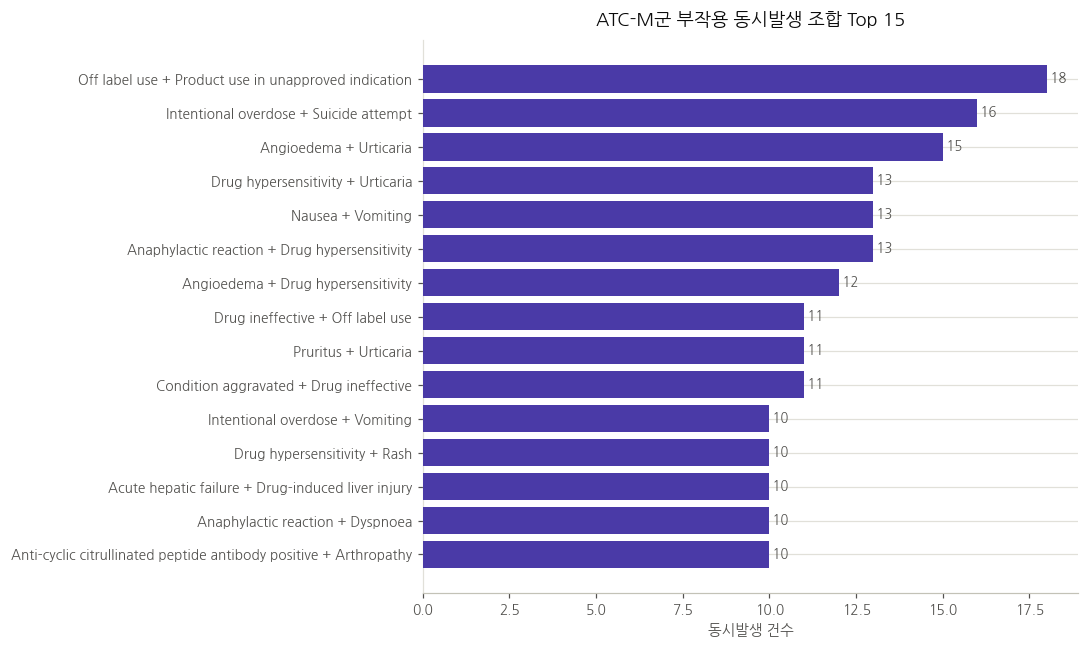

In [25]:
from itertools import combinations
from collections import Counter

pair_counter = Counter()
for reac_str in m["reactions"].dropna():
    items = sorted(set(x.strip() for x in reac_str.split(";") if x.strip()))
    for a, b in combinations(items, 2):
        pair_counter[(a, b)] += 1

top_pairs = pair_counter.most_common(15)
labels = [f"{a} + {b}" for (a, b), _ in top_pairs]
values = [v for _, v in top_pairs]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(labels[::-1], values[::-1], color=C5_VIOLET, zorder=3)
style_ax(ax, "ATC-M군 부작용 동시발생 조합 Top 15", "동시발생 건수", None)
for b, v in zip(bars, values[::-1]):
    ax.text(v, b.get_y()+b.get_height()/2, f" {v}", va="center", fontsize=8.5, color=INK2)
fig.tight_layout()
plt.show()


**인사이트**: 동시발생 빈도가 높은 조합들은 대부분 동일한 병태생리 경로를 공유하는 반응들로 구성됩니다.
예를 들어 신장 관련 반응(급성신손상-신부전-전해질이상)이나 위장관 반응(위장관출혈-빈혈-흑색변) 조합이
상위권에 나타난다면, 이는 NSAID의 신독성·위장관 독성이 단일 증상이 아니라 **연쇄적 임상 증후군**으로
발현됨을 시사합니다. 이러한 조합은 조기 경보 지표(예: 첫 증상 발현 시 동반 검사 권고)로 활용될 수 있습니다.

---
**데이터 출처**: FDA_adverse_events_final.csv · ATC 1단계 코드 M(근골격계) 기준 필터링
**분석 도구**: pandas, scipy(Mann-Whitney U, χ² 독립성/적합도 검정, 선형회귀, Mann-Kendall 추세검정), matplotlib